## Session 27 - Q10

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [4]:
'''
Load and Select Numerical Features
'''

wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print(df.head())

print("\nShape:", df.shape)

X = df

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [5]:
'''
Scale Data and Apply DBSCAN
'''

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["Cluster"] = dbscan.fit_predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
-1    178
Name: count, dtype: int64


In [6]:
'''
Apply PCA
'''

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["Cluster"] = df["Cluster"]

print(df_pca.head())

        PC1       PC2  Cluster
0  3.316751  1.443463       -1
1  2.209465 -0.333393       -1
2  2.516740  1.031151       -1
3  3.757066  2.756372       -1
4  1.008908  0.869831       -1


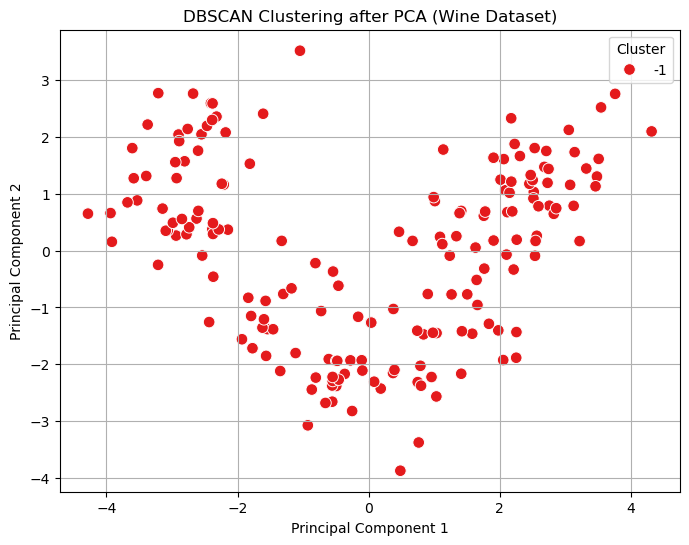

In [7]:
'''
Visualize PCA Results
'''

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("DBSCAN Clustering after PCA (Wine Dataset)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()